In [1]:
import numpy as np
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn

In [26]:
#importing data
data = pd.read_csv('C:/Users/124628/Downloads/creditcard/creditcard.csv')

In [30]:
print(data.shape)
print(data.columns)

(284807, 31)
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [33]:
print(data.iloc[10])

Time      10.000000
V1         1.449044
V2        -1.176339
V3         0.913860
V4        -1.375667
V5        -1.971383
V6        -0.629152
V7        -1.423236
V8         0.048456
V9        -1.720408
V10        1.626659
V11        1.199644
V12       -0.671440
V13       -0.513947
V14       -0.095045
V15        0.230930
V16        0.031967
V17        0.253415
V18        0.854344
V19       -0.221365
V20       -0.387226
V21       -0.009302
V22        0.313894
V23        0.027740
V24        0.500512
V25        0.251367
V26       -0.129478
V27        0.042850
V28        0.016253
Amount     7.800000
Class      0.000000
Name: 10, dtype: float64


In [34]:
data = data.sample(frac = 0.2, random_state = 1)
print(data.shape)

(56961, 31)


In [36]:
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]

outlier_fraction = len(fraud) / float(len(valid))
print(outlier_fraction)

print('Fraud Cases: {}'.format(len(fraud)))
print('Valid Cases: {}'.format(len(valid)))

0.0015296972254457222
Fraud Cases: 87
Valid Cases: 56874


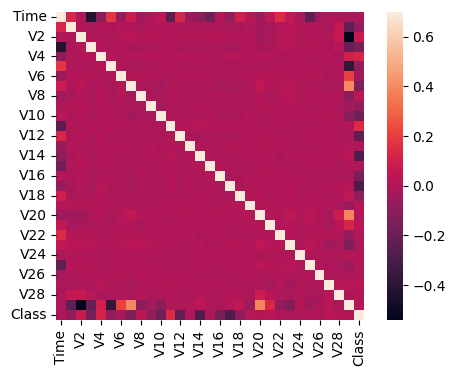

In [40]:
# correlation matrix
corrmat = data.corr()
fig = plt.figure(figsize = (6, 4))

sns.heatmap(corrmat, vmax = 0.7, square = True)
plt.show()

In [43]:
columns = data.columns.tolist()
columns = [c for c in columns if c not in ['Class']]
# store the variable we will be predicting on which is class
target = 'Class'

# X includes everything except our class column
X = data[columns]
# Y includes all the class labels for each sample
# this is also one-dimensional
Y = data[target]

# print the shapes of X and Y
print(X.shape)
print(Y.shape)

(56961, 30)
(56961,)


In [48]:
print(data['Class'].value_counts())

Class
0    56874
1       87
Name: count, dtype: int64


In [57]:
ratio=int(data['Class'].value_counts()[0]/data['Class'].value_counts()[1])

In [50]:
X = data.drop(columns=['Class', 'Time'])  # Drop target and timestamp
y = data['Class']

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [60]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


              precision    recall  f1-score   support

           0       1.00      0.97      0.98     11376
           1       0.04      0.82      0.08        17

    accuracy                           0.97     11393
   macro avg       0.52      0.90      0.53     11393
weighted avg       1.00      0.97      0.98     11393

ROC-AUC: 0.9392865268470257


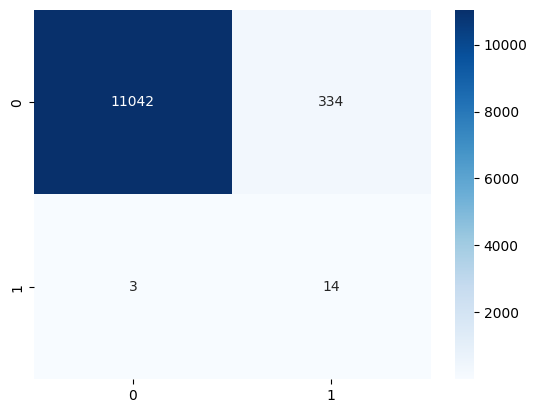

In [61]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

In [62]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11376
           1       0.83      0.59      0.69        17

    accuracy                           1.00     11393
   macro avg       0.92      0.79      0.84     11393
weighted avg       1.00      1.00      1.00     11393

ROC-AUC: 0.9095102175891453


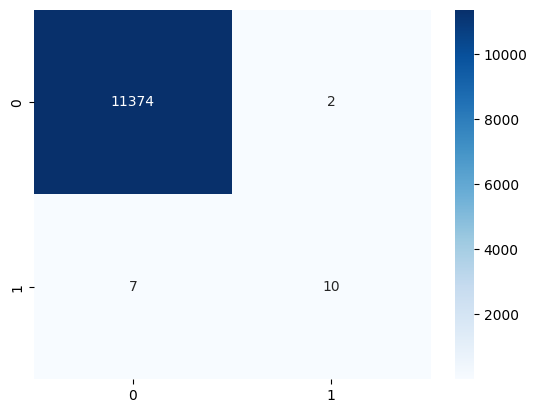

In [63]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()
